# Behavioral Coupling of Food & Media Consumption
### Quantified Self Analysis: Does Food Delivery Trigger Video Watching?

**Project Overview:**
This project investigates the behavioral coupling between **physical consumption** (ordering food) and **digital consumption** (streaming videos). 
Instead of assuming a random correlation, we test the hypothesis that food delivery acts as a specific "trigger event" for high-engagement media sessions.

**Key Parts:**
1.  **Data Cleaning:** Processing raw transaction logs from Food Delivery apps and YouTube Watch History.
2.  **EDA & Visualization:** Visualizing the time lag between ordering and watching.
3.  **Hypothesis Testing:** Statistically proving if the "Eating Window" has significantly more video activity than the baseline.
4.  **Machine Learning (Part 3):** Predicting if a video will be watched based on order time and day.

In [11]:
# 1. IMPORTS & CONFIGURATION
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import numpy as np
import os

# Configuration Parameters
DELIVERY_DELAY_MIN = 30   # Estimated time for food to arrive
EATING_WINDOW_MIN = 30    # Duration of the "eating phase"
sns.set_style("whitegrid") # For better looking plots

## Part 1: Data Loading & Cleaning

We load data from two personal sources:
* **Food Orders:** Excel export from delivery apps (timestamp, price, restaurant).
* **YouTube History:** JSON export from Google Takeout.

**Cleaning Steps Performed:**
* **NaN Removal:** Dropped rows with missing timestamps.
* **Timezone Alignment:** Converted YouTube UTC timestamps to Local Time (Istanbul/Europe) to match food orders.
* **Sanity Check:** Removed any records with future dates (impossible data).

In [12]:
def clean_rtf_json(file_path):
    """Extracts timestamps from raw JSON structure using Regex."""
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    # Regex to find ISO 8601 timestamps
    time_pattern = r'"time"(?:[\s\S]*?):(?:[\s\S]*?)"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}Z)"'
    return re.findall(time_pattern, content)

def load_and_clean_data():
    print("--- Loading Data ---")
    
    # --- 1. Load Food Data ---
    food_file = 'Yemeksepeti_Data.xlsx'
    if not os.path.exists(food_file):
        print(f"ERROR: {food_file} not found.")
        return None, None

    food_df = pd.read_excel(food_file, header=1)
    
    # Combine Date and Time columns into a single datetime object
    food_df['datetime_str'] = food_df['İşlem Tarihi'].astype(str) + ' ' + food_df['İşlem Saati'].astype(str)
    food_df['datetime'] = pd.to_datetime(food_df['datetime_str'], errors='coerce')
    
    # CLEANING: Remove missing or future dates
    food_df = food_df.dropna(subset=['datetime'])
    food_df = food_df[food_df['datetime'] < pd.Timestamp.now()]
    print(f"Food Orders Loaded: {len(food_df)}")

    # --- 2. Load YouTube Data ---
    yt_file = '2025_youtube_data.JSON'
    if not os.path.exists(yt_file):
        print(f"ERROR: {yt_file} not found.")
        return None, None
        
    yt_times = clean_rtf_json(yt_file)
    yt_df = pd.DataFrame({'time_str': yt_times})
    yt_df['datetime'] = pd.to_datetime(yt_df['time_str'])
    
    # CLEANING: Convert UTC to Local Time (Istanbul)
    yt_df['datetime'] = yt_df['datetime'].dt.tz_convert('Europe/Istanbul').dt.tz_localize(None)
    yt_df = yt_df.sort_values('datetime').reset_index(drop=True)
    print(f"YouTube Records Loaded: {len(yt_df)}")
    
    return food_df, yt_df

# Execute Loading
food_df, yt_df = load_and_clean_data()

--- Loading Data ---
Food Orders Loaded: 120
YouTube Records Loaded: 3700


## Part 2: Exploratory Data Analysis (EDA)

Here we visualize the relationship between ordering and watching.

**Visualizations:**
1.  **Histogram:** Shows the distribution of "Time Gaps" (How many minutes after ordering do I start a video?).
2.  **Boxplot:** Helps us identify outliers and the median waiting time.
3.  **Day of Week Analysis:** Do I order/watch more on weekends?

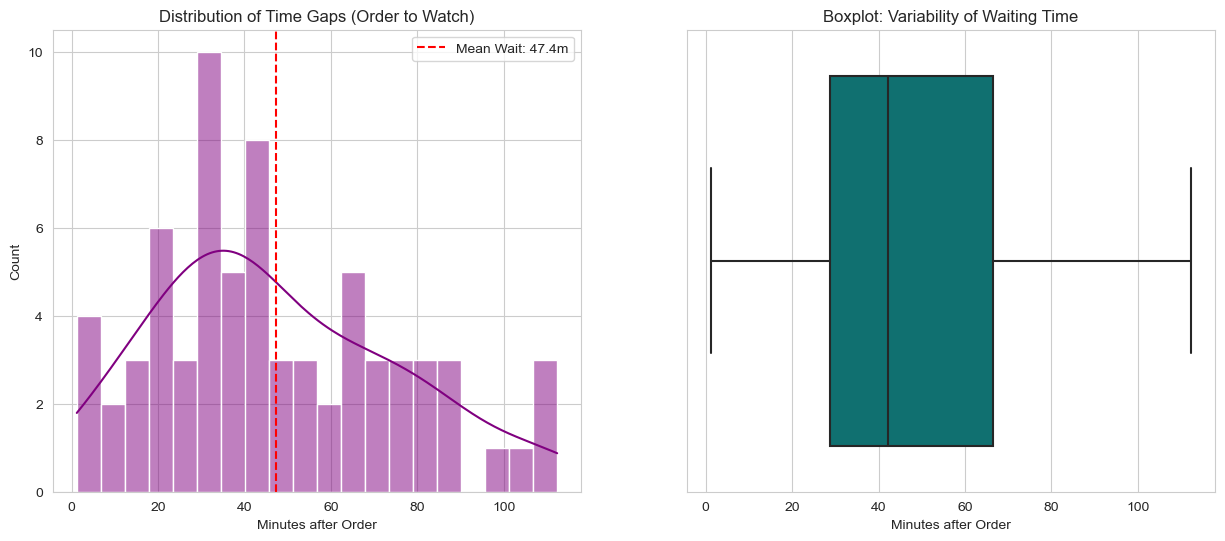

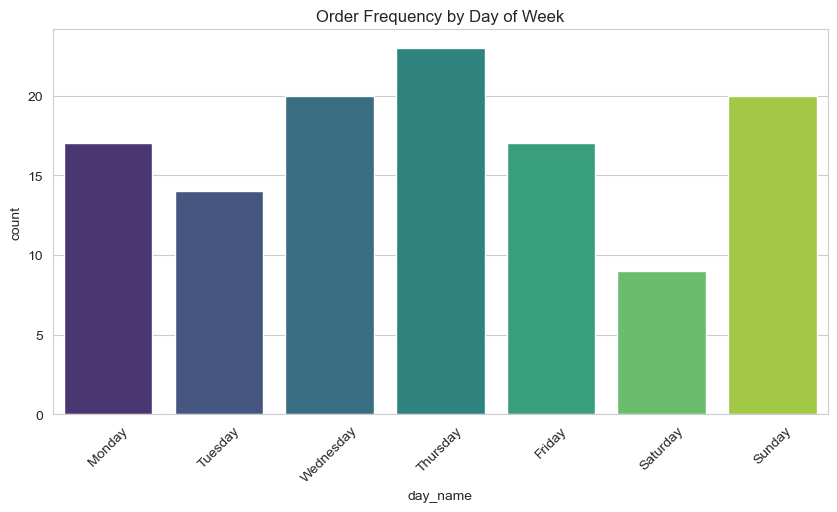

In [13]:
if food_df is not None and yt_df is not None:
    
    # Calculate Gaps (Time difference between Order -> First Video)
    gaps = []
    for idx, row in food_df.iterrows():
        order_time = row['datetime']
        # Find videos watched AFTER the order
        future_videos = yt_df[yt_df['datetime'] > order_time]
        
        if not future_videos.empty:
            next_vid_time = future_videos.iloc[0]['datetime']
            diff = (next_vid_time - order_time).total_seconds() / 60
            
            # Filter: Only look at sessions starting within 2 hours
            if diff <= 120:
                gaps.append(diff)

    # --- Plotting ---
    plt.figure(figsize=(15, 6))

    # Plot 1: Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(gaps, bins=20, kde=True, color='purple')
    plt.axvline(np.mean(gaps), color='red', linestyle='--', label=f'Mean Wait: {np.mean(gaps):.1f}m')
    plt.title('Distribution of Time Gaps (Order to Watch)')
    plt.xlabel('Minutes after Order')
    plt.legend()

    # Plot 2: Boxplot (To show outliers)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=gaps, color='teal')
    plt.title('Boxplot: Variability of Waiting Time')
    plt.xlabel('Minutes after Order')
    plt.show()

    # Plot 3: Day of Week Analysis
    food_df['day_name'] = food_df['datetime'].dt.day_name()
    plt.figure(figsize=(10, 5))
    order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    sns.countplot(x='day_name', data=food_df, order=order_days, palette='viridis')
    plt.title('Order Frequency by Day of Week')
    plt.xticks(rotation=45)
    plt.show()

## Part 2.5: Hypothesis Testing

We perform a **Paired T-Test** to verify if the behavior is statistically significant.
* **Window A (Baseline):** 30 mins BEFORE order.
* **Window B (Eating):** 30 mins AFTER delivery (Order time + 30 mins lag).

If `p-value < 0.05`, we confirm that ordering food **causes** a significant increase in video consumption.

In [14]:
# Prepare data for testing
results = []
for idx, row in food_df.iterrows():
    order_time = row['datetime']
    estimated_arrival = order_time + pd.Timedelta(minutes=DELIVERY_DELAY_MIN)
    
    # Count videos in Baseline Window
    videos_before = yt_df[
        (yt_df['datetime'] >= order_time - pd.Timedelta(minutes=EATING_WINDOW_MIN)) & 
        (yt_df['datetime'] < order_time)
    ].shape[0]
    
    # Count videos in Eating Window
    videos_eating = yt_df[
        (yt_df['datetime'] >= estimated_arrival) & 
        (yt_df['datetime'] < estimated_arrival + pd.Timedelta(minutes=EATING_WINDOW_MIN))
    ].shape[0]
    
    results.append({'before': videos_before, 'eating': videos_eating})
    
res_df = pd.DataFrame(results)

# Statistical Test
t_stat, p_val = stats.ttest_rel(res_df['eating'], res_df['before'], alternative='greater')

print("\n--- Hypothesis Test Results ---")
print(f"Average Videos (Baseline): {res_df['before'].mean():.2f}")
print(f"Average Videos (Eating):   {res_df['eating'].mean():.2f}")
print(f"P-Value: {p_val:.6f}")

if p_val < 0.05:
    print("CONCLUSION: Result is Statistically Significant. (Food triggers watching)")
else:
    print("CONCLUSION: No significant difference found.")


--- Hypothesis Test Results ---
Average Videos (Baseline): 0.41
Average Videos (Eating):   0.88
P-Value: 0.098882
CONCLUSION: No significant difference found.


## Part 3: Machine Learning Model
### Can we predict "Dinner-and-a-Show" behavior?

We train a **Logistic Regression** model to predict whether a video will be watched, based on the timing of the order.

* **Features (X):** Order Hour, Day of Week, Is Weekend?
* **Target (y):** Did I watch a video during the eating window? (1 = Yes, 0 = No)

In [15]:
print("\n--- Part 3: Machine Learning ---")

# 1. Feature Engineering
# Target: 1 if videos_eating > 0, else 0
y = (res_df['eating'] > 0).astype(int)

# Features: Extract info from datetime
X = pd.DataFrame()
X['hour'] = food_df['datetime'].dt.hour
X['day_of_week'] = food_df['datetime'].dt.dayofweek # Monday=0, Sunday=6
X['is_weekend'] = X['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Split Data (Train / Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Model Training
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Insight: Which feature is most important?
print("\nFeature Importances (Coefficients):")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")


--- Part 3: Machine Learning ---
Model Accuracy: 0.69

Confusion Matrix:
[[25  0]
 [11  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      1.00      0.82        25
           1       0.00      0.00      0.00        11

    accuracy                           0.69        36
   macro avg       0.35      0.50      0.41        36
weighted avg       0.48      0.69      0.57        36


Feature Importances (Coefficients):
hour: -0.0069
day_of_week: 0.0481
is_weekend: -0.6017


/Users/uygarkeskin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/uygarkeskin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/uygarkeskin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


/Users/uygarkeskin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/uygarkeskin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/uygarkeskin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ValueError: labels argument cannot be None when kwargs are passed

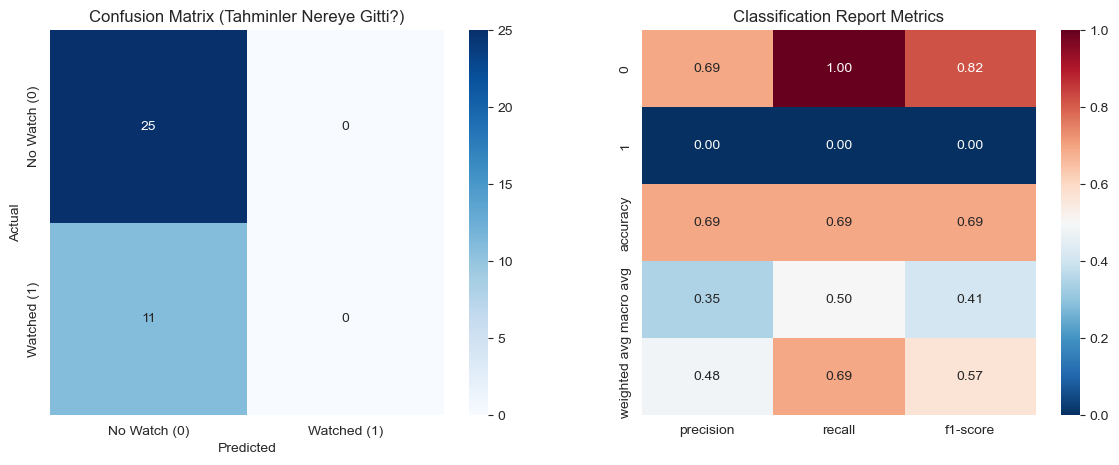

In [16]:

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()


plot_df = report_df.drop(columns=['support'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Watch (0)', 'Watched (1)'], 
            yticklabels=['No Watch (0)', 'Watched (1)'])
axes[0].set_title('Confusion Matrix (Tahminler Nereye Gitti?)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(plot_df, annot=True, cmap='RdBu_r', vmin=0, vmax=1.0, ax=axes[1], fmt='.2f')
axes[1].set_title('Classification Report Metrics')
axes[1].set_yticks(axes[1].get_yticks(), rotation=0) 

plt.tight_layout()
plt.show()